# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
|Hilal Tsabitul Azmi Arba'i|5054251008|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [26]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import (
    GaussianNB,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

In [2]:
data = pd.read_csv("diabetes.csv")
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [5]:
data.shape

(768, 9)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

Outcome
0    500
1    268
Name: count, dtype: int64

Proporsi kelas (%): 
Outcome
0    65.1
1    34.9
Name: count, dtype: float64


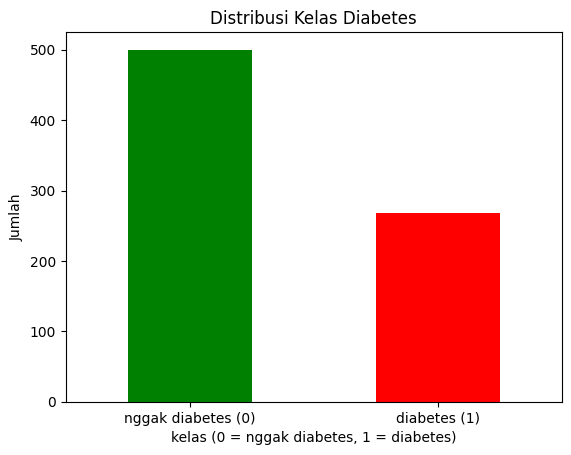

In [ ]:
outcome_counts = data["Outcome"].value_counts()

ax = outcome_counts.plot(
    kind="bar",
    color=["green","red"],
    title="Distribusi Kelas Diabetes"
)

ax.set_xlabel("kelas (0 = nggak diabetes, 1 = diabetes)")
ax.set_ylabel("Jumlah")
ax.set_xticklabels(["nggak diabetes (0)", "diabetes (1)"], rotation= 0)

print(outcome_counts)
print("\nProporsi kelas (%): ")
print((outcome_counts/len(data)*100).round(2))

In [ ]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.

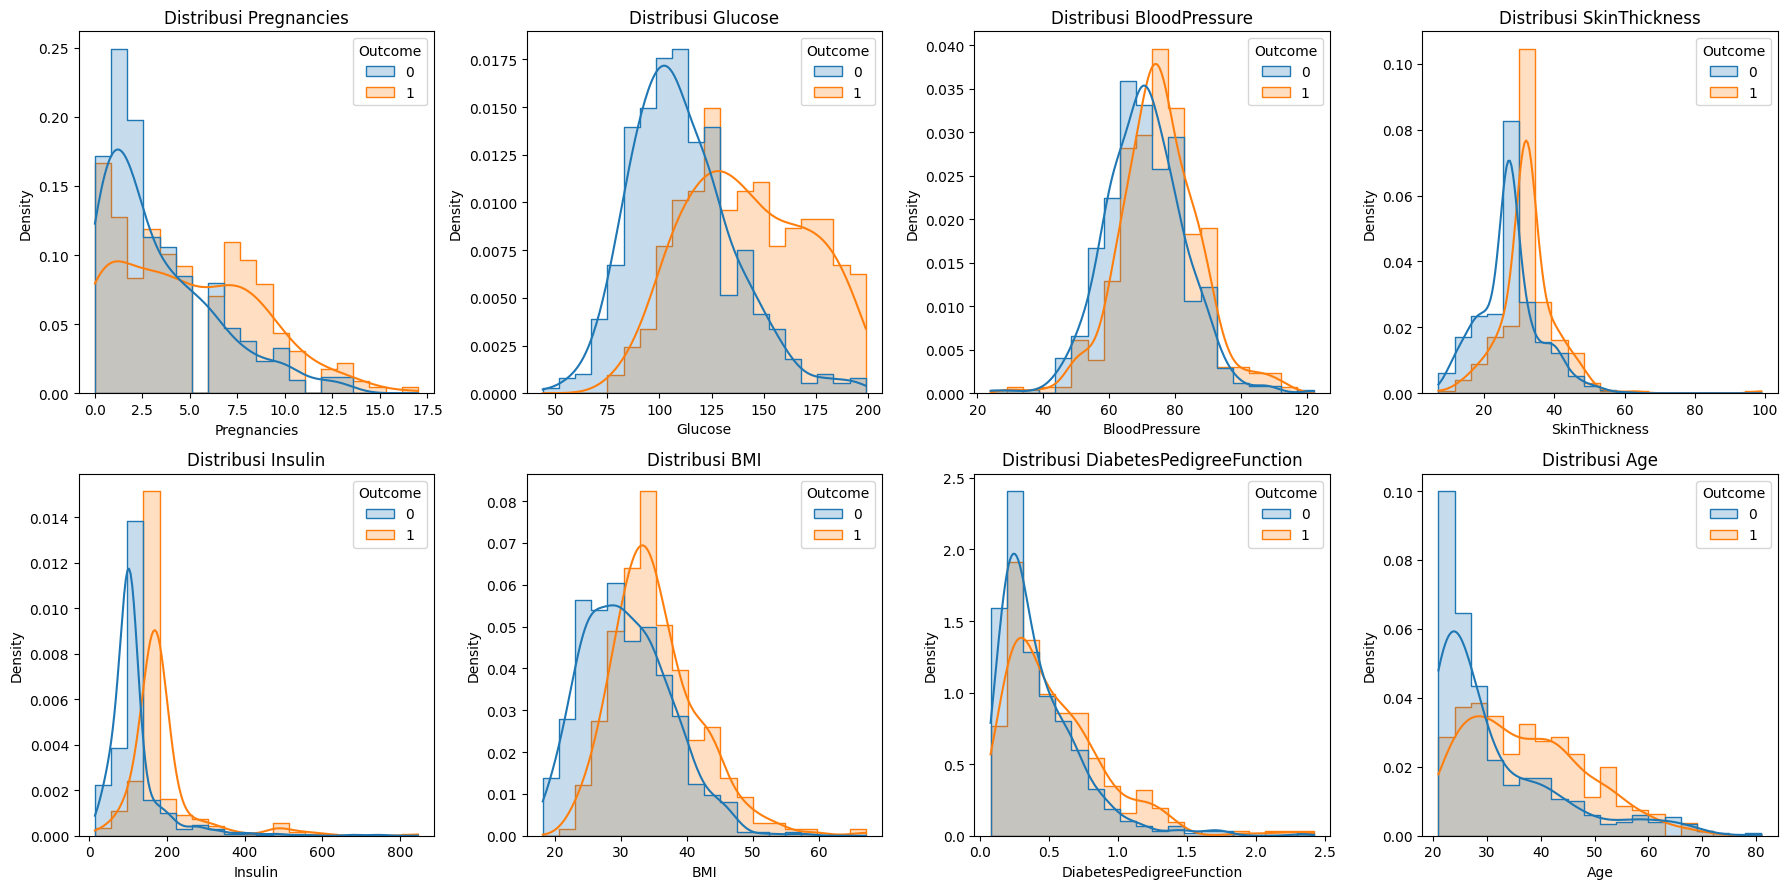

In [12]:
features = data.drop(columns="Outcome").columns

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, feature in zip(axes, features):
    sns.histplot(
        data=data,
        x=feature,
        hue="Outcome",
        kde=True,
        bins=20,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax
    )
    ax.set_title(f"Distribusi {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
# Tampilkan heatmap korelasi antar fitur.

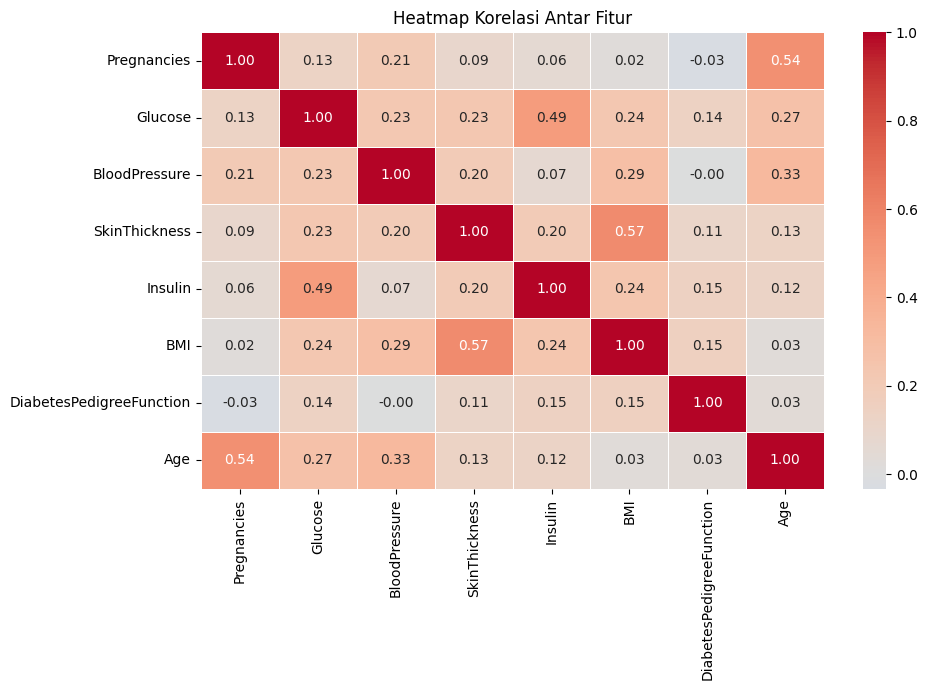

In [13]:
correlation_matrix = data[features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Heatmap Korelasi Antar Fitur")
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [ ]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

In [18]:
def jumlah(kolom):
    print(f"jumlah data pada kolom {kolom} yang berisikan nilai 0: ", data[kolom].isin(["0"]).sum())
    
jumlah("Glucose")
jumlah("BloodPressure")
jumlah("Insulin")
jumlah("BMI")

jumlah data pada kolom Glucose yang berisikan nilai 0:  0
jumlah data pada kolom BloodPressure yang berisikan nilai 0:  0
jumlah data pada kolom Insulin yang berisikan nilai 0:  0
jumlah data pada kolom BMI yang berisikan nilai 0:  0


In [ ]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

nggak ada nilai nol yak ges yak, apalagi kalau kita cek dari describe nya nilai min nya nggak ada yang nol

In [ ]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

In [20]:
x = data[features]
y = data["Outcome"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("x_train shape", x_train.shape)
print("x_test shape", x_test.shape)

x_train shape (614, 8)
x_test shape (154, 8)


In [ ]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.

In [22]:
imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(x_train)
X_test_imputed = imputer.transform(x_test)

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

X_test_scaled = scaler.transform(
    X_test_imputed
)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [ ]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.

In [27]:
gnb_model = GaussianNB()

gnb_model.fit(
    X_train_scaled,
    y_train
)

,priors,None
,var_smoothing,1e-09


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

In [28]:

gnb_pred = gnb_model.predict(
    X_test_scaled
)

gnb_probability = gnb_model.predict_proba(
    X_test_scaled
)[:, 1]

## 3.2 Logistic Regression

In [ ]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.

In [30]:
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

In [31]:
logreg_pred = logreg_model.predict(
    X_test_scaled
)

logreg_probability = (
    logreg_model
    .predict_proba(X_test_scaled)[:, 1]
)

In [32]:
logreg_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logreg_balanced.fit(
    X_train_scaled,
    y_train
)

logreg_balanced_pred = (
    logreg_balanced.predict(
        X_test_scaled
    )
)

logreg_balanced_probability = (
    logreg_balanced
    .predict_proba(X_test_scaled)[:, 1]
)

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.

In [33]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    positive_label="p"
):
    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        )
    }

In [34]:
evaluation_results = [
    evaluate_model(
        "Gaussian NB",
        y_test,
        gnb_pred,
        positive_label=1
    ),

    evaluate_model(
        "Logreg",
        y_test,
        logreg_pred,
        positive_label=1
    ),

    evaluate_model(
        "logreg balanced",
        y_test,
        logreg_balanced_pred,
        positive_label=1
    )
]

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian NB,0.727273,0.603448,0.648148,0.625000
1,Logreg,0.707792,0.588235,0.555556,0.571429
2,logreg balanced,0.746753,0.608696,0.777778,0.682927


In [ ]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.

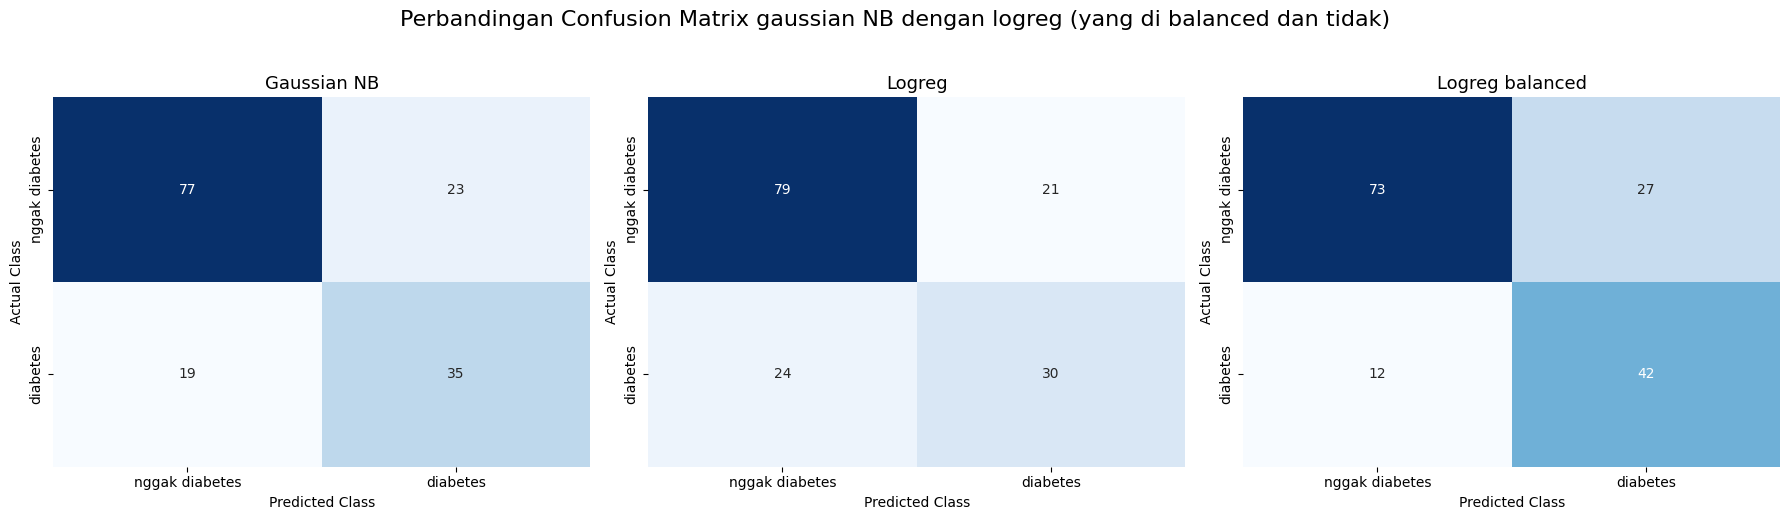

In [35]:
labels = ["e", "p"]

model_predictions = {
    "Gaussian NB": gnb_pred,
    "Logreg": logreg_pred,
    "Logreg balanced": logreg_balanced_pred
}

labels = [0, 1]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5)
)


for ax, (model_name, y_pred) in zip(axes,model_predictions.items()):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "nggak diabetes",
            "diabetes"
        ],
        yticklabels=[
            "nggak diabetes",
            "diabetes"
        ],
        cbar=False,
        ax=ax
    )

    ax.set_title(
        model_name,
        fontsize=13
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "Actual Class"
    )


plt.suptitle(
    "Perbandingan Confusion Matrix gaussian NB dengan logreg (yang di balanced dan tidak)",
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

In [ ]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.

In [36]:
positive_label = 1

y_test_binary = y_test.astype(int)


def get_positive_probability(model, X_test_model, positive_label=1):
    positive_class_index = np.where(
        model.classes_ == positive_label
    )[0][0]

    probabilities = model.predict_proba(
        X_test_model
    )

    return probabilities[:, positive_class_index]

In [41]:
categorical_probability = get_positive_probability(
    gnb_model,
    X_test_scaled,
    positive_label=1
)

bernoulli_probability = get_positive_probability(
    logreg_model,
    X_test_scaled,
    positive_label=1
)

multinomial_probability = get_positive_probability(
    logreg_balanced,
    X_test_scaled,
    positive_label=1
)

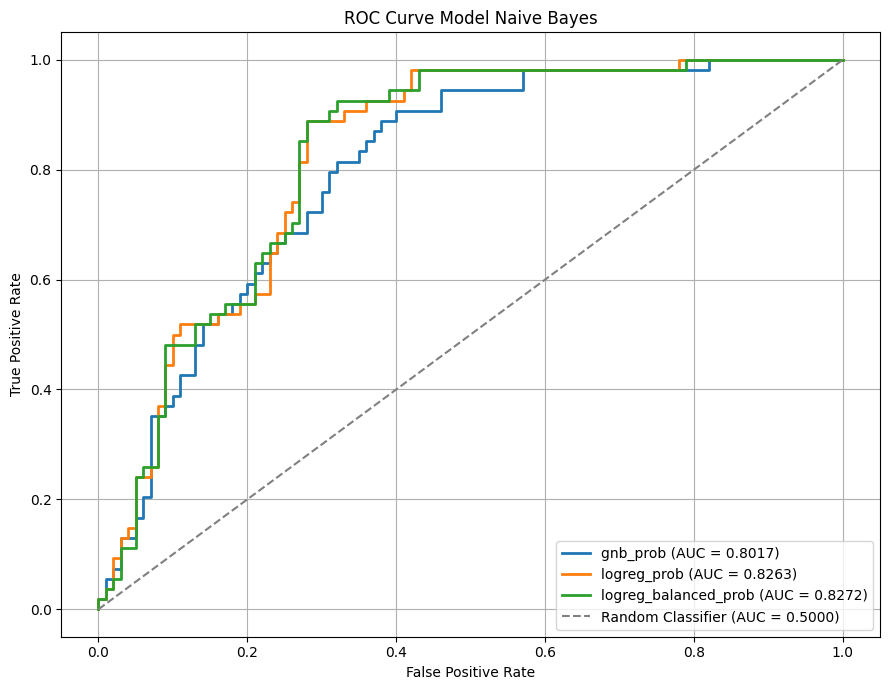

In [42]:
probability_results = {
    "gnb_prob": gnb_probability,
    "logreg_prob": logreg_probability,
    "logreg_balanced_prob": logreg_balanced_probability
}

plt.figure(figsize=(9, 7))

for model_name, y_probability in (probability_results.items()):
    fpr, tpr, thresholds = roc_curve(
        y_test_binary,
        y_probability
    )

    auc_score = roc_auc_score(
        y_test_binary,
        y_probability
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {auc_score:.4f})"
        )
    )

# Garis baseline untuk tebakan acak
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Model Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

In [43]:
auc_results = []

for model_name, y_probability in (probability_results.items()):
    auc_score = roc_auc_score(
        y_test_binary,
        y_probability
    )

    auc_results.append({
        "Model": model_name,
        "AUC": auc_score
    })


auc_table = pd.DataFrame(auc_results)

auc_table = (
    auc_table
    .sort_values(
        by="AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(auc_table.round(4))

,Model,AUC
0,logreg_balanced_prob,0.8272
1,logreg_prob,0.8263
2,gnb_prob,0.8017


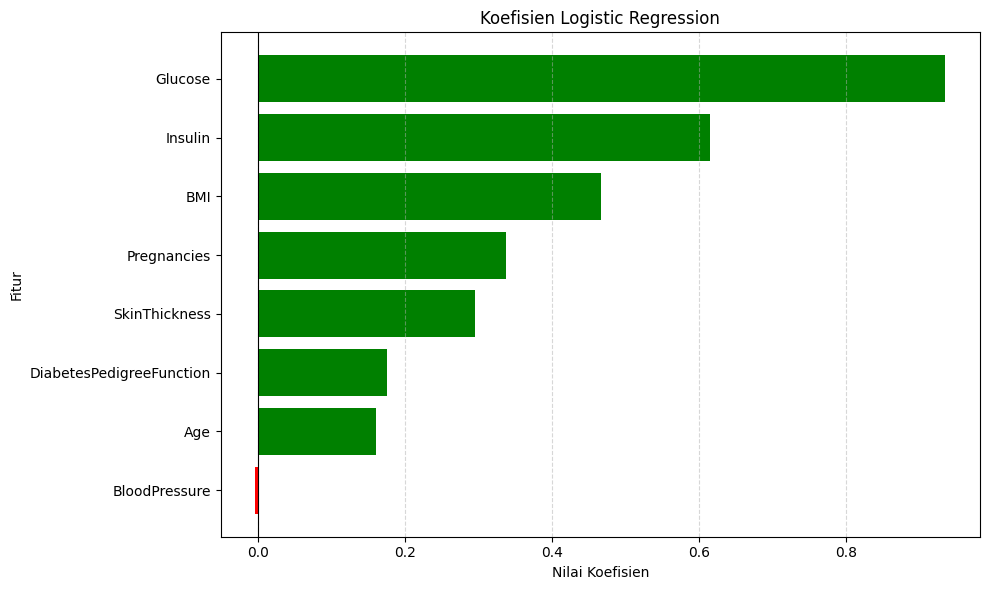

In [44]:
coefficients = logreg_model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values("Coefficient")

plt.figure(figsize=(10, 6))

colors = [
    "green" if coefficient > 0 else "red"
    for coefficient in coefficient_df["Coefficient"]
]

plt.barh(
    coefficient_df["Feature"],
    coefficient_df["Coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Nilai Koefisien")
plt.ylabel("Fitur")
plt.title("Koefisien Logistic Regression")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Eksperimen dilakukan dengan membandingkan tiga konfigurasi model, yaitu Gaussian Naive Bayes, Logistic Regression tanpa penanganan khusus terhadap ketidakseimbangan kelas, serta Logistic Regression dengan class_weight="balanced". Berdasarkan tabel evaluasi, Gaussian Naive Bayes memperoleh accuracy sebesar 72,73%, precision sebesar 60,34%, recall sebesar 64,81%, dan F1-score sebesar 62,50%. Logistic Regression tanpa class weighting menghasilkan accuracy sebesar 70,78%, precision sebesar 58,82%, recall sebesar 55,56%, dan F1-score sebesar 57,14%. Sementara itu, Logistic Regression dengan class_weight="balanced" memberikan hasil terbaik pada sebagian besar metrik, dengan accuracy sebesar 74,68%, precision sebesar 60,87%, recall sebesar 77,78%, dan F1-score sebesar 68,29%.

Perbandingan tersebut menunjukkan bahwa Logistic Regression tanpa balancing mempunyai performa paling rendah, terutama pada recall kelas diabetes. Model tersebut hanya mampu mengenali sekitar 55,56% dari seluruh pasien yang sebenarnya termasuk kelas diabetes. Ketidakseimbangan kelas menyebabkan model cenderung lebih baik dalam memprediksi kelas non-diabetes karena jumlah sampel kelas tersebut lebih banyak. Setelah ditambahkan class_weight="balanced", kesalahan pada kelas minoritas mendapat penalti yang lebih besar selama proses pelatihan. Hasilnya, recall kelas diabetes meningkat cukup besar dari 55,56% menjadi 77,78%. F1-score juga meningkat dari 57,14% menjadi 68,29%, yang menunjukkan bahwa keseimbangan antara precision dan recall menjadi lebih baik. Accuracy juga meningkat dari 70,78% menjadi 74,68%, sehingga penggunaan class weighting pada eksperimen ini tidak hanya memperbaiki kemampuan model mengenali kelas diabetes, tetapi juga meningkatkan performa keseluruhan.

Hasil confusion matrix memperjelas perbedaan perilaku ketiga model. Gaussian Naive Bayes mengklasifikasikan 77 data non-diabetes dan 35 data diabetes dengan benar. Model ini melakukan 23 false positive, yaitu data non-diabetes yang diprediksi sebagai diabetes, serta 19 false negative, yaitu data diabetes yang diprediksi sebagai non-diabetes. Logistic Regression tanpa balancing mampu mengklasifikasikan 79 data non-diabetes dan 30 data diabetes dengan benar. Walaupun jumlah prediksi benar pada kelas non-diabetes lebih tinggi daripada Gaussian Naive Bayes, model ini menghasilkan 24 false negative, paling banyak di antara ketiga konfigurasi. Hal ini menunjukkan bahwa Logistic Regression tanpa balancing lebih cenderung memilih kelas mayoritas dan lebih sering melewatkan kelas diabetes.

Setelah menggunakan class_weight="balanced", Logistic Regression berhasil mengklasifikasikan 42 dari 54 data diabetes dengan benar dan hanya menghasilkan 12 false negative. Angka tersebut merupakan jumlah false negative paling kecil di antara ketiga model. Namun, peningkatan kemampuan mengenali kelas diabetes diikuti dengan meningkatnya false positive menjadi 27, dibandingkan 21 pada Logistic Regression standar dan 23 pada Gaussian Naive Bayes. Hal ini menunjukkan adanya pertukaran antara recall dan precision. Logistic Regression balanced menjadi lebih sensitif dalam memberikan prediksi diabetes, sehingga lebih sedikit pasien diabetes yang terlewat, tetapi lebih banyak pasien non-diabetes yang ikut diprediksi sebagai diabetes. Meskipun demikian, pada eksperimen ini penurunan false negative cukup besar dan F1-score tetap meningkat, sehingga pertukaran tersebut memberikan hasil yang lebih baik secara keseluruhan.

Berdasarkan ROC Curve, ketiga model mempunyai kemampuan pemisahan kelas yang cukup baik karena seluruh kurva berada jauh di atas garis random classifier. Gaussian Naive Bayes memperoleh AUC sebesar 0,8017, Logistic Regression tanpa balancing memperoleh AUC sebesar 0,8263, dan Logistic Regression balanced memperoleh AUC tertinggi sebesar 0,8272. Hasil ini menunjukkan bahwa Logistic Regression mempunyai kemampuan yang lebih baik daripada Gaussian Naive Bayes dalam memberikan peringkat probabilitas antara kelas diabetes dan non-diabetes pada berbagai nilai threshold. Selisih AUC antara Logistic Regression standar dan balanced hanya sebesar 0,0009, sehingga class weighting tidak banyak mengubah kemampuan dasar Logistic Regression dalam memisahkan kedua kelas. Pengaruh utama class weighting terlihat pada keputusan klasifikasi ketika threshold default digunakan, yaitu model menjadi lebih banyak memprediksi kelas diabetes sehingga recall meningkat.

Gaussian Naive Bayes menghasilkan performa yang lebih baik daripada Logistic Regression standar berdasarkan accuracy, recall, dan F1-score, tetapi mempunyai AUC yang lebih rendah. Perbedaan tersebut menunjukkan bahwa performa pada satu threshold tidak selalu sama dengan kemampuan pemisahan pada seluruh kemungkinan threshold. Gaussian Naive Bayes memberikan hasil klasifikasi yang lebih baik pada threshold keputusan yang digunakan, tetapi Logistic Regression menghasilkan probabilitas yang secara umum lebih baik dalam mengurutkan data diabetes dan non-diabetes. Gaussian Naive Bayes menghitung probabilitas kelas berdasarkan distribusi Gaussian setiap fitur dengan asumsi bahwa fitur-fitur saling independen secara kondisional terhadap kelas. Asumsi independensi tersebut kemungkinan tidak sepenuhnya terpenuhi karena beberapa karakteristik kesehatan dapat saling berkaitan. Logistic Regression tidak menggunakan asumsi independensi antarfitur dan mempelajari hubungan gabungan antara setiap fitur dengan probabilitas kelas diabetes. Hal ini dapat menjelaskan mengapa kedua varian Logistic Regression memperoleh AUC yang lebih tinggi.

Grafik koefisien Logistic Regression menunjukkan bahwa Glucose memiliki koefisien positif paling besar, diikuti oleh Insulin, BMI, Pregnancies, dan SkinThickness. Karena seluruh fitur telah melalui StandardScaler, besar koefisien dapat dibandingkan secara lebih layak karena fitur berada pada skala yang sama. Koefisien positif menunjukkan bahwa peningkatan nilai fitur berkaitan dengan peningkatan log-odds model dalam memprediksi kelas diabetes, dengan asumsi fitur lainnya tetap. Pada hasil eksperimen ini, Glucose menjadi fitur yang memberikan kontribusi positif paling kuat terhadap prediksi diabetes. Insulin dan BMI juga memberikan kontribusi positif yang relatif besar. DiabetesPedigreeFunction dan Age mempunyai koefisien positif yang lebih kecil, sedangkan BloodPressure mempunyai koefisien negatif yang sangat kecil dan mendekati nol. Hal tersebut menunjukkan bahwa setelah mempertimbangkan fitur lainnya, BloodPressure hanya memberikan kontribusi yang sangat kecil terhadap keputusan model pada eksperimen ini. Koefisien tersebut menunjukkan hubungan yang dipelajari model dan tidak dapat langsung diartikan sebagai hubungan sebab-akibat medis.

Secara keseluruhan, Logistic Regression dengan class_weight="balanced" merupakan konfigurasi terbaik dalam eksperimen ini. Model tersebut memperoleh accuracy, recall, F1-score, dan AUC tertinggi, masing-masing sebesar 74,68%, 77,78%, 68,29%, dan 0,8272. Keunggulan paling penting terletak pada berkurangnya false negative dari 24 pada Logistic Regression standar menjadi 12 pada Logistic Regression balanced. Gaussian Naive Bayes berada pada posisi kedua dengan F1-score sebesar 62,50%, sedangkan Logistic Regression standar menghasilkan F1-score terendah sebesar 57,14%. Hasil ini menunjukkan bahwa penanganan ketidakseimbangan kelas melalui class weighting memberikan manfaat nyata terhadap kemampuan Logistic Regression dalam mengenali kelas diabetes.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Berdasarkan eksperimen yang telah dilakukan, Logistic Regression dengan class_weight="balanced" dipilih sebagai model terbaik karena menghasilkan performa paling seimbang dalam mengenali kelas diabetes dan non-diabetes. Model ini memiliki accuracy sebesar 74,68%, precision sebesar 60,87%, recall sebesar 77,78%, F1-score sebesar 68,29%, dan AUC sebesar 0,8272. Dibandingkan Logistic Regression standar, penggunaan class weighting berhasil meningkatkan recall kelas diabetes secara signifikan dan mengurangi jumlah false negative menjadi setengahnya, meskipun jumlah false positive mengalami peningkatan. Gaussian Naive Bayes memberikan performa yang lebih baik daripada Logistic Regression standar pada threshold default, tetapi masih berada di bawah Logistic Regression balanced berdasarkan recall, F1-score, dan AUC.

Untuk eksperimen selanjutnya, model dapat dievaluasi menggunakan Stratified K-Fold Cross Validation agar hasilnya tidak hanya bergantung pada satu pembagian train-test. Nilai parameter regularisasi C pada Logistic Regression juga dapat diuji untuk mencari konfigurasi yang lebih optimal. Selain itu, beberapa nilai threshold dapat dibandingkan menggunakan validation set untuk memperoleh keseimbangan precision dan recall yang sesuai dengan tujuan eksperimen. Metode penanganan imbalance lainnya, seperti Random Oversampling atau SMOTE pada data training, juga dapat dibandingkan dengan class_weight="balanced". Proses resampling harus dilakukan hanya pada training set agar tidak terjadi data leakage. Metrik seperti Precision-Recall AUC juga dapat ditambahkan karena memberikan perhatian lebih besar terhadap performa kelas positif ketika distribusi kelas tidak seimbang.

penggunaan AI pada tugas ini hanya pada bagian penyempurnaan teks analisis dan kesimpulan dan saran. selain itu, penggunaan AI dilakukan juga pada strategi handle imbalanced data